In [1]:
# ============================================================
# FRCRN Notebook - Hücre 1
# A100 / GPU kontrolü
# ============================================================

!nvidia-smi

import torch

print("CUDA kullanılabilir mi?:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU adı:", torch.cuda.get_device_name(0))
    print("CUDA sürümü:", torch.version.cuda)
else:
    print("GPU bulunamadı. Runtime > Change runtime type > GPU seçmelisin.")

Tue May 26 18:32:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# ============================================================
# FRCRN Notebook - Hücre 2
# Google Drive bağlama ve klasör yapısı
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/SLESS_FRCRN")

CLEAN_DIR = BASE_DIR / "data" / "clean_16k"
NOISE_DIR = BASE_DIR / "data" / "noise_16k"
PAIR_DIR  = BASE_DIR / "data" / "pairs_16k"

MODEL_DIR = BASE_DIR / "models"
LOG_DIR   = BASE_DIR / "logs"
OUT_DIR   = BASE_DIR / "outputs"

for d in [CLEAN_DIR, NOISE_DIR, PAIR_DIR, MODEL_DIR, LOG_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Klasörler hazır:")
for d in [BASE_DIR, CLEAN_DIR, NOISE_DIR, PAIR_DIR, MODEL_DIR, LOG_DIR, OUT_DIR]:
    print(d)

Mounted at /content/drive
Klasörler hazır:
/content/drive/MyDrive/SLESS_FRCRN
/content/drive/MyDrive/SLESS_FRCRN/data/clean_16k
/content/drive/MyDrive/SLESS_FRCRN/data/noise_16k
/content/drive/MyDrive/SLESS_FRCRN/data/pairs_16k
/content/drive/MyDrive/SLESS_FRCRN/models
/content/drive/MyDrive/SLESS_FRCRN/logs
/content/drive/MyDrive/SLESS_FRCRN/outputs


In [3]:
# ============================================================
# FRCRN Notebook - Hücre 3
# Gerekli paketlerin kurulumu
# ============================================================

!pip install -q \
torchinfo \
pesq \
pystoi \
librosa \
soundfile \
datasets \
transformers \
accelerate

print("✅ Paket kurulumları tamamlandı")

  Preparing metadata (setup.py) ... done
✅ Paket kurulumları tamamlandı


In [4]:
# ============================================================
# FRCRN Notebook - Hücre 4
# Importlar + CFG ayarları
# ============================================================

import os
import gc
import json
import math
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

from pesq import pesq
from pystoi.stoi import stoi

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CFG = {

    # audio
    "sample_rate": 16000,

    # dataset
    "n_fleurs": 2000,
    "n_cv": 12000,

    # DNS noise
    "noise_files": 659,

    # segment
    "segment_seconds": 4.0,
    "segment_samples": int(16000 * 4.0),

    # snr
    "snr_min": -5,
    "snr_max": 20,

    # training
    "batch_size": 8,
    "epochs": 30,
    "learning_rate": 5e-5,

    # dataloader
    "num_workers": 0,

    # split
    "train_ratio": 0.9,
    "val_ratio": 0.1,

    # evaluation
    "eval_items": 200,

    # DNS noise source
    "dns_noise_source": "/content/drive/MyDrive/noise"
}

print("✅ Importlar ve ayarlar hazır")
print("DEVICE:", DEVICE)

if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

print("\nCFG:")
print(json.dumps(CFG, indent=2))

✅ Importlar ve ayarlar hazır
DEVICE: cuda
GPU: NVIDIA A100-SXM4-40GB

CFG:
{
  "sample_rate": 16000,
  "n_fleurs": 2000,
  "n_cv": 12000,
  "noise_files": 659,
  "segment_seconds": 4.0,
  "segment_samples": 64000,
  "snr_min": -5,
  "snr_max": 20,
  "batch_size": 8,
  "epochs": 30,
  "learning_rate": 5e-05,
  "num_workers": 0,
  "train_ratio": 0.9,
  "val_ratio": 0.1,
  "eval_items": 200,
  "dns_noise_source": "/content/drive/MyDrive/noise"
}


In [5]:
# ============================================================
# FRCRN Notebook - Hücre 5
# Ses okuma, yazma, normalize ve mixing fonksiyonları
# ============================================================

def peak_normalize(audio, peak=0.9, eps=1e-8):
    audio = np.asarray(audio, dtype=np.float32).reshape(-1)

    if audio.size == 0:
        return None

    max_val = np.max(np.abs(audio))

    if max_val < eps:
        return None

    audio = audio / max_val * peak
    return audio.astype(np.float32)


def write_wav(path, audio, sr):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    audio = np.asarray(audio, dtype=np.float32).reshape(-1)
    audio = np.nan_to_num(audio)

    sf.write(str(path), audio, sr)


def load_wav_any(path, target_sr=16000):
    try:
        audio, sr = librosa.load(str(path), sr=target_sr, mono=True)
        audio = np.asarray(audio, dtype=np.float32).reshape(-1)

        if audio.size == 0:
            return None

        if not np.isfinite(audio).all():
            return None

        return audio

    except Exception:
        return None


def load_hf_audio(item, target_sr=16000):
    try:
        audio_obj = item.get("audio", None)

        if audio_obj is None:
            return None

        # Yeni HuggingFace AudioDecoder formatı
        if hasattr(audio_obj, "get_all_samples"):
            samples = audio_obj.get_all_samples()
            arr = samples.data

            if hasattr(arr, "numpy"):
                arr = arr.numpy()

            sr = samples.sample_rate

        # Eski dict formatı
        elif isinstance(audio_obj, dict):
            arr = audio_obj.get("array", None)
            sr = audio_obj.get("sampling_rate", None)

        else:
            return None

        if arr is None or sr is None:
            return None

        arr = np.asarray(arr, dtype=np.float32).reshape(-1)

        if arr.size == 0:
            return None

        if sr != target_sr:
            arr = librosa.resample(arr, orig_sr=sr, target_sr=target_sr)

        arr = peak_normalize(arr, 0.9)

        return arr

    except Exception:
        return None


def fix_length(audio, length):
    audio = np.asarray(audio, dtype=np.float32).reshape(-1)

    if audio.size == 0:
        audio = np.zeros(length, dtype=np.float32)

    if len(audio) > length:
        start = random.randint(0, len(audio) - length)
        return audio[start:start + length].astype(np.float32)

    if len(audio) < length:
        pad = length - len(audio)
        return np.pad(audio, (0, pad), mode="constant").astype(np.float32)

    return audio.astype(np.float32)


def mix_with_snr(clean, noise, snr_db):
    clean = np.asarray(clean, dtype=np.float32).reshape(-1)
    noise = np.asarray(noise, dtype=np.float32).reshape(-1)

    if clean.size == 0:
        clean = np.zeros(CFG["segment_samples"], dtype=np.float32)

    if noise.size == 0:
        noise = np.random.randn(clean.size).astype(np.float32) * 0.01

    if len(noise) < len(clean):
        repeat = int(np.ceil(len(clean) / len(noise)))
        noise = np.tile(noise, repeat)

    noise = noise[:len(clean)]

    clean_power = np.mean(clean ** 2) + 1e-8
    noise_power = np.mean(noise ** 2) + 1e-8

    target_noise_power = clean_power / (10 ** (snr_db / 10))
    scale = np.sqrt(target_noise_power / noise_power)

    noisy = clean + noise * scale

    max_val = np.max(np.abs(noisy)) + 1e-8

    if max_val > 1.0:
        noisy = noisy / max_val * 0.99
        clean = clean / max_val * 0.99

    return noisy.astype(np.float32).reshape(-1), clean.astype(np.float32).reshape(-1)


def safe_load_audio(path, sr):
    audio = load_wav_any(path, sr)

    if audio is None:
        return None

    audio = np.asarray(audio, dtype=np.float32).reshape(-1)

    if audio.size < sr:
        return None

    if not np.isfinite(audio).all():
        return None

    audio = peak_normalize(audio, 0.9)

    if audio is None:
        return None

    return audio.astype(np.float32).reshape(-1)


print("✅ Ses yardımcı fonksiyonları hazır")

✅ Ses yardımcı fonksiyonları hazır


In [6]:
# ============================================================
# FRCRN Notebook - Hücre 6
# Drive'daki gerçek DNS noise klasörünü kontrol etme
# ============================================================

DNS_SOURCE_DIR = Path(CFG["dns_noise_source"])

print("DNS noise klasörü var mı?:", DNS_SOURCE_DIR.exists())
print("DNS noise yolu:", DNS_SOURCE_DIR)

dns_files = []

for ext in ["*.wav", "*.flac", "*.mp3", "*.ogg"]:
    dns_files.extend(DNS_SOURCE_DIR.rglob(ext))

dns_files = sorted(dns_files)

print("Bulunan gerçek noise dosyası:", len(dns_files))

print("\nİlk 10 noise dosyası:")
for f in dns_files[:10]:
    print(f)

if len(dns_files) == 0:
    raise RuntimeError("DNS noise klasöründe audio dosyası bulunamadı. Drive yolunu kontrol et.")
else:
    print("\n✅ DNS noise klasörü hazır.")

DNS noise klasörü var mı?: True
DNS noise yolu: /content/drive/MyDrive/noise
Bulunan gerçek noise dosyası: 659

İlk 10 noise dosyası:
/content/drive/MyDrive/noise/0CaA0wAIbKc.wav
/content/drive/MyDrive/noise/0LnYEuBp6uU.wav
/content/drive/MyDrive/noise/0Lpb1lba5yY.wav
/content/drive/MyDrive/noise/0LqI1bux4Ow.wav
/content/drive/MyDrive/noise/0LrTnI-BYSI.wav
/content/drive/MyDrive/noise/0LvBAEYGpsA.wav
/content/drive/MyDrive/noise/0hAK5f1tDok.wav
/content/drive/MyDrive/noise/0lq5Oey7ChY.wav
/content/drive/MyDrive/noise/0ls9KaQJAs0.wav
/content/drive/MyDrive/noise/0lsf6jybC0M.wav

✅ DNS noise klasörü hazır.


In [7]:
# ============================================================
# FRCRN Notebook - Hücre 7
# DNS noise subset hazırlama
# ============================================================

def prepare_dns_noise_subset(source_dir, target_dir, n_max, sr):
    target_dir.mkdir(parents=True, exist_ok=True)

    existing = sorted(target_dir.glob("dns_noise_*.wav"))

    if len(existing) >= min(n_max, len(dns_files)):
        print(f"✅ DNS subset zaten hazır: {len(existing)} dosya")
        return existing

    source_files = []
    for ext in ["*.wav", "*.flac", "*.mp3", "*.ogg"]:
        source_files.extend(Path(source_dir).rglob(ext))

    source_files = sorted(source_files)
    random.Random(SEED).shuffle(source_files)
    source_files = source_files[:min(n_max, len(source_files))]

    saved = []
    failed = 0

    pbar = tqdm(source_files, desc="DNS noise hazırlanıyor")

    for idx, src in enumerate(pbar):
        try:
            audio = safe_load_audio(src, sr)

            if audio is None:
                failed += 1
                continue

            audio = peak_normalize(audio, 0.8)

            if audio is None:
                failed += 1
                continue

            out_path = target_dir / f"dns_noise_{idx:05d}.wav"
            write_wav(out_path, audio, sr)

            saved.append(out_path)

            pbar.set_postfix({
                "saved": len(saved),
                "failed": failed
            })

        except Exception:
            failed += 1

    print(f"\n✅ Hazırlanan DNS noise: {len(saved)}")
    print(f"❌ Atlanan: {failed}")

    return saved


noise_paths = prepare_dns_noise_subset(
    DNS_SOURCE_DIR,
    NOISE_DIR,
    CFG["noise_files"],
    CFG["sample_rate"]
)

print("\nKullanılacak noise dosyası:", len(noise_paths))

print("\nİlk 5 subset noise:")
for p in noise_paths[:5]:
    print(p)

DNS noise hazırlanıyor:   0%|          | 0/659 [00:00<?, ?it/s]


✅ Hazırlanan DNS noise: 659
❌ Atlanan: 0

Kullanılacak noise dosyası: 659

İlk 5 subset noise:
/content/drive/MyDrive/SLESS_FRCRN/data/noise_16k/dns_noise_00000.wav
/content/drive/MyDrive/SLESS_FRCRN/data/noise_16k/dns_noise_00001.wav
/content/drive/MyDrive/SLESS_FRCRN/data/noise_16k/dns_noise_00002.wav
/content/drive/MyDrive/SLESS_FRCRN/data/noise_16k/dns_noise_00003.wav
/content/drive/MyDrive/SLESS_FRCRN/data/noise_16k/dns_noise_00004.wav


In [22]:
# ============================================================
# FRCRN Notebook - Hücre 8
# Temiz Türkçe veri hazırlama
# FLEURS + CommonVoice17 TR
# ============================================================

def save_clean_batch(source_name, items, n_max, target_dir):

    saved_paths = []
    failed = 0

    pbar = tqdm(items, total=n_max, desc=f"{source_name} kaydediliyor")

    for item in pbar:

        if len(saved_paths) >= n_max:
            break

        audio = load_hf_audio(item, CFG["sample_rate"])

        if audio is None:
            failed += 1
            continue

        # NOT:
        # Burada fix_length uygulanmıyor.
        # Clean ses doğal uzunluğuyla kaydediliyor.
        # Random crop/padding işlemi Dataset içinde yapılacak.

        out_path = target_dir / f"{source_name}_{len(saved_paths):06d}.wav"

        write_wav(out_path, audio, CFG["sample_rate"])

        saved_paths.append(out_path)

        pbar.set_postfix({
            "saved": len(saved_paths),
            "failed": failed
        })

    print(f"✅ {source_name}: {len(saved_paths)} kayıt, {failed} atlandı")

    return saved_paths


def prepare_fleurs():

    existing = sorted(CLEAN_DIR.glob("fleurs_*.wav"))

    if len(existing) >= CFG["n_fleurs"]:
        print(f"✅ FLEURS hazır: {len(existing)} dosya")
        return existing[:CFG["n_fleurs"]]

    print("📥 FLEURS tr_tr indiriliyor...")

    from datasets import concatenate_datasets

    splits = []

    for split in ["train", "validation", "test"]:

        ds = load_dataset(
            "google/fleurs",
            "tr_tr",
            split=split
        )

        print(f"FLEURS {split}: {len(ds)}")

        splits.append(ds)

    all_ds = concatenate_datasets(splits)

    all_ds = all_ds.shuffle(seed=SEED)

    all_ds = all_ds.select(
        range(min(CFG["n_fleurs"], len(all_ds)))
    )

    paths = save_clean_batch(
        "fleurs",
        all_ds,
        CFG["n_fleurs"],
        CLEAN_DIR
    )

    del all_ds
    gc.collect()

    return paths


def prepare_cv():

    existing = sorted(CLEAN_DIR.glob("cv17_*.wav"))

    if len(existing) >= CFG["n_cv"]:
        print(f"✅ CV17 hazır: {len(existing)} dosya")
        return existing[:CFG["n_cv"]]

    print("📥 CommonVoice17 TR indiriliyor...")

    cv_ds = load_dataset(
        "ysdede/commonvoice_17_tr_fixed",
        split="train"
    )

    print("CV17 train:", len(cv_ds))

    cv_ds = cv_ds.shuffle(seed=SEED)

    paths = save_clean_batch(
        "cv17",
        cv_ds,
        CFG["n_cv"],
        CLEAN_DIR
    )

    del cv_ds
    gc.collect()

    return paths


fleurs_paths = prepare_fleurs()

cv_paths = prepare_cv()

all_clean_paths = fleurs_paths + cv_paths

random.Random(SEED).shuffle(all_clean_paths)

print("\nToplam temiz Türkçe ses:", len(all_clean_paths))

print("\nİlk 5 temiz ses:")

for p in all_clean_paths[:5]:
    print(p)

📥 FLEURS tr_tr indiriliyor...
FLEURS train: 2526
FLEURS validation: 338
FLEURS test: 743


fleurs kaydediliyor:   0%|          | 0/2000 [00:00<?, ?it/s]

✅ fleurs: 2000 kayıt, 0 atlandı
📥 CommonVoice17 TR indiriliyor...
CV17 train: 26501


cv17 kaydediliyor:   0%|          | 0/12000 [00:00<?, ?it/s]

✅ cv17: 12000 kayıt, 0 atlandı

Toplam temiz Türkçe ses: 14000

İlk 5 temiz ses:
/content/drive/MyDrive/SLESS_FRCRN/data/clean_16k/cv17_008048.wav
/content/drive/MyDrive/SLESS_FRCRN/data/clean_16k/cv17_008365.wav
/content/drive/MyDrive/SLESS_FRCRN/data/clean_16k/cv17_003159.wav
/content/drive/MyDrive/SLESS_FRCRN/data/clean_16k/cv17_006823.wav
/content/drive/MyDrive/SLESS_FRCRN/data/clean_16k/fleurs_000623.wav


In [20]:
for f in CLEAN_DIR.glob("fleurs_*.wav"):
    f.unlink()

for f in CLEAN_DIR.glob("cv17_*.wav"):
    f.unlink()

print("✅ Eski fixed-length clean dosyaları silindi")

✅ Eski fixed-length clean dosyaları silindi


In [23]:
# ============================================================
# FRCRN Notebook - Hücre 9
# Noisy-clean veri seti ve DataLoader
# ============================================================

class SpeechEnhancementDataset(Dataset):

    def __init__(
        self,
        clean_paths,
        noise_paths,
        segment_samples,
        sr,
        snr_min=-5,
        snr_max=20
    ):

        self.clean_paths = list(clean_paths)
        self.noise_paths = list(noise_paths)
        self.segment_samples = segment_samples
        self.sr = sr
        self.snr_min = snr_min
        self.snr_max = snr_max

    def __len__(self):
        return len(self.clean_paths)

    def __getitem__(self, idx):

        clean = None
        noise = None

        # Sağlam clean dosya bul
        for _ in range(10):

            clean_path = self.clean_paths[idx % len(self.clean_paths)]
            clean = safe_load_audio(clean_path, self.sr)

            if clean is not None:
                break

            idx = random.randint(0, len(self.clean_paths) - 1)

        # Sağlam noise dosya bul
        for _ in range(10):

            noise_path = random.choice(self.noise_paths)
            noise = safe_load_audio(noise_path, self.sr)

            if noise is not None:
                break

        if clean is None:
            clean = np.zeros(self.segment_samples, dtype=np.float32)

        if noise is None:
            noise = np.random.randn(self.segment_samples).astype(np.float32) * 0.01

        clean = fix_length(clean, self.segment_samples)
        noise = fix_length(noise, self.segment_samples)

        clean = peak_normalize(clean, 0.9)
        noise = peak_normalize(noise, 0.8)

        snr = random.uniform(self.snr_min, self.snr_max)

        noisy, clean = mix_with_snr(clean, noise, snr)

        noisy = np.asarray(noisy, dtype=np.float32).reshape(-1)
        clean = np.asarray(clean, dtype=np.float32).reshape(-1)

        return (
            torch.tensor(noisy, dtype=torch.float32),
            torch.tensor(clean, dtype=torch.float32)
        )


all_clean_paths = sorted(CLEAN_DIR.glob("*.wav"))
noise_paths = sorted(NOISE_DIR.glob("dns_noise_*.wav"))

random.Random(SEED).shuffle(all_clean_paths)

n_total = len(all_clean_paths)
n_train = int(n_total * CFG["train_ratio"])

train_clean = all_clean_paths[:n_train]
val_clean = all_clean_paths[n_train:]

train_dataset = SpeechEnhancementDataset(
    train_clean,
    noise_paths,
    CFG["segment_samples"],
    CFG["sample_rate"],
    CFG["snr_min"],
    CFG["snr_max"]
)

val_dataset = SpeechEnhancementDataset(
    val_clean,
    noise_paths,
    CFG["segment_samples"],
    CFG["sample_rate"],
    CFG["snr_min"],
    CFG["snr_max"]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    drop_last=False
)

print("Toplam clean:", n_total)
print("Train clean:", len(train_clean))
print("Val clean:", len(val_clean))
print("Noise:", len(noise_paths))
print("Train batch:", len(train_loader))
print("Val batch:", len(val_loader))

noisy_batch, clean_batch = next(iter(train_loader))

print("Noisy batch shape:", noisy_batch.shape)
print("Clean batch shape:", clean_batch.shape)
print("Noisy finite:", torch.isfinite(noisy_batch).all().item())
print("Clean finite:", torch.isfinite(clean_batch).all().item())

Toplam clean: 14000
Train clean: 12600
Val clean: 1400
Noise: 659
Train batch: 1575
Val batch: 175
Noisy batch shape: torch.Size([8, 64000])
Clean batch shape: torch.Size([8, 64000])
Noisy finite: True
Clean finite: True


In [24]:
# ============================================================
# FRCRN Notebook - Hücre 10
# FRCRN benzeri complex spectrogram model mimarisi
# ============================================================

class FRCRNConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.PReLU(),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.PReLU()
        )

    def forward(self, x):
        return self.block(x)


class FRCRN(nn.Module):
    def __init__(self, n_fft=512, hop_length=128, hidden_size=128):
        super().__init__()

        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = n_fft
        self.hidden_size = hidden_size

        # Complex spectrogram: real + imag = 2 kanal
        self.enc1 = FRCRNConvBlock(2, 32)
        self.enc2 = FRCRNConvBlock(32, 64)
        self.enc3 = FRCRNConvBlock(64, 96)

        self.bottleneck_in = nn.LazyLinear(hidden_size)

        self.rnn = nn.GRU(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.bottleneck_out = nn.LazyLinear(96 * 257)

        self.dec3 = FRCRNConvBlock(96, 64)
        self.dec2 = FRCRNConvBlock(64, 32)
        self.dec1 = FRCRNConvBlock(32, 16)

        # complex mask output: real mask + imag mask
        self.mask_head = nn.Conv2d(16, 2, kernel_size=1)

    def forward(self, waveform):

        window = torch.hann_window(
            self.win_length,
            device=waveform.device
        )

        spec = torch.stft(
            waveform,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            window=window,
            return_complex=True
        )

        real = spec.real
        imag = spec.imag

        x = torch.stack([real, imag], dim=1)

        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)

        b, c, f, t = x.shape

        z = x.permute(0, 3, 1, 2).contiguous()
        z = z.view(b, t, c * f)

        z = self.bottleneck_in(z)
        z, _ = self.rnn(z)
        z = self.bottleneck_out(z)

        z = z.view(b, t, 96, 257)
        z = z.permute(0, 2, 3, 1).contiguous()

        z = self.dec3(z)
        z = self.dec2(z)
        z = self.dec1(z)

        mask = self.mask_head(z)

        mask = mask[:, :, :real.shape[1], :real.shape[2]]

        mask_real = torch.tanh(mask[:, 0])
        mask_imag = torch.tanh(mask[:, 1])

        enhanced_real = real * mask_real - imag * mask_imag
        enhanced_imag = real * mask_imag + imag * mask_real

        enhanced_spec = torch.complex(enhanced_real, enhanced_imag)

        enhanced = torch.istft(
            enhanced_spec,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            window=window,
            length=waveform.shape[-1]
        )

        enhanced = torch.nan_to_num(enhanced)

        return enhanced


model = FRCRN().to(DEVICE)

with torch.no_grad():
    test_noisy = noisy_batch.to(DEVICE)
    test_out = model(test_noisy)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["learning_rate"],
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✅ FRCRN model hazır")
print("Toplam parametre:", f"{total_params:,}")
print("Eğitilebilir parametre:", f"{trainable_params:,}")
print("Test input shape:", test_noisy.shape)
print("Test output shape:", test_out.shape)

✅ FRCRN model hazır
Toplam parametre: 10,325,358
Eğitilebilir parametre: 10,325,358
Test input shape: torch.Size([8, 64000])
Test output shape: torch.Size([8, 64000])


In [25]:
# ============================================================
# FRCRN Notebook - Hücre 11
# Perceptual kalite odaklı loss
# L1 + Multi-Scale STFT + düşük SI-SDR
# ============================================================

def si_sdr(est, ref, eps=1e-8):
    est = est - torch.mean(est, dim=-1, keepdim=True)
    ref = ref - torch.mean(ref, dim=-1, keepdim=True)

    ref_energy = torch.sum(ref ** 2, dim=-1, keepdim=True) + eps
    projection = torch.sum(est * ref, dim=-1, keepdim=True) * ref / ref_energy
    noise = est - projection

    ratio = torch.sum(projection ** 2, dim=-1) / (torch.sum(noise ** 2, dim=-1) + eps)
    ratio = torch.clamp(ratio, min=eps, max=1e6)

    out = 10 * torch.log10(ratio)

    return torch.nan_to_num(out, nan=-30.0, posinf=30.0, neginf=-30.0)


def multi_scale_stft_loss(est, ref):
    loss = 0.0

    configs = [
        (256, 64),
        (512, 128),
        (1024, 256),
    ]

    for n_fft, hop in configs:
        window = torch.hann_window(n_fft, device=est.device)

        est_spec = torch.stft(
            est,
            n_fft=n_fft,
            hop_length=hop,
            win_length=n_fft,
            window=window,
            return_complex=True
        )

        ref_spec = torch.stft(
            ref,
            n_fft=n_fft,
            hop_length=hop,
            win_length=n_fft,
            window=window,
            return_complex=True
        )

        est_mag = torch.abs(est_spec)
        ref_mag = torch.abs(ref_spec)

        loss = loss + F.l1_loss(
            torch.log1p(est_mag),
            torch.log1p(ref_mag)
        )

    return loss / len(configs)


def enhancement_loss(est, clean):
    est = torch.nan_to_num(est)
    clean = torch.nan_to_num(clean)

    l1 = F.l1_loss(est, clean)
    stft_l = multi_scale_stft_loss(est, clean)
    sisdr_l = -torch.mean(si_sdr(est, clean))

    total = 0.45 * l1 + 0.45 * stft_l + 0.10 * sisdr_l

    return torch.nan_to_num(total, nan=10.0, posinf=10.0, neginf=10.0)


print("✅ FRCRN loss fonksiyonları hazır")

with torch.no_grad():
    test_loss = enhancement_loss(test_out, clean_batch.to(DEVICE))
    test_sisdr = si_sdr(test_out, clean_batch.to(DEVICE)).mean()

print("Test loss:", float(test_loss))
print("Test SI-SDR:", float(test_sisdr))

✅ FRCRN loss fonksiyonları hazır
Test loss: 0.33230650424957275
Test SI-SDR: -2.2811007499694824


In [26]:
# ============================================================
# FRCRN Notebook - Hücre 12
# Stabil model eğitim döngüsü
# ============================================================

best_val_loss = float("inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "val_si_sdr": []
}

BEST_MODEL_PATH = MODEL_DIR / "frcrn_best_model.pt"
LAST_MODEL_PATH = MODEL_DIR / "frcrn_last_model.pt"

for epoch in range(1, CFG["epochs"] + 1):

    model.train()
    train_losses = []
    skipped_batches = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{CFG['epochs']} - Train")

    for noisy, clean in pbar:
        noisy = noisy.to(DEVICE)
        clean = clean.to(DEVICE)

        noisy = torch.nan_to_num(noisy)
        clean = torch.nan_to_num(clean)

        optimizer.zero_grad()

        enhanced = model(noisy)
        enhanced = torch.nan_to_num(enhanced)

        loss = enhancement_loss(enhanced, clean)

        if not torch.isfinite(loss):
            skipped_batches += 1
            continue

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_losses.append(loss.item())

        pbar.set_postfix({
            "loss": np.mean(train_losses) if train_losses else 0,
            "skipped": skipped_batches
        })

    train_loss = float(np.mean(train_losses)) if train_losses else float("inf")

    model.eval()
    val_losses = []
    val_sisdrs = []

    with torch.no_grad():
        for noisy, clean in tqdm(val_loader, desc=f"Epoch {epoch}/{CFG['epochs']} - Val"):
            noisy = noisy.to(DEVICE)
            clean = clean.to(DEVICE)

            noisy = torch.nan_to_num(noisy)
            clean = torch.nan_to_num(clean)

            enhanced = model(noisy)
            enhanced = torch.nan_to_num(enhanced)

            loss = enhancement_loss(enhanced, clean)
            score = si_sdr(enhanced, clean).mean()

            if torch.isfinite(loss):
                val_losses.append(loss.item())

            if torch.isfinite(score):
                val_sisdrs.append(score.item())

    val_loss = float(np.mean(val_losses)) if val_losses else float("inf")
    val_si_sdr = float(np.mean(val_sisdrs)) if val_sisdrs else -30.0

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_si_sdr"].append(val_si_sdr)

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "CFG": CFG,
        "history": history
    }, LAST_MODEL_PATH)

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "CFG": CFG,
            "history": history,
            "best_val_loss": best_val_loss,
            "val_si_sdr": val_si_sdr
        }, BEST_MODEL_PATH)

        best_msg = "✅ best model kaydedildi"
    else:
        best_msg = ""

    print(
        f"Epoch {epoch}/{CFG['epochs']} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val SI-SDR: {val_si_sdr:.2f} dB | "
        f"Skipped: {skipped_batches} "
        f"{best_msg}"
    )

print("\nEğitim tamamlandı.")
print("Best model:", BEST_MODEL_PATH)
print("Last model:", LAST_MODEL_PATH)

Epoch 1/30 - Train:   0%|          | 0/1575 [00:00<?, ?it/s]

Epoch 1/30 - Val:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: -1.1428 | Val Loss: -1.3300 | Val SI-SDR: 13.91 dB | Skipped: 0 ✅ best model kaydedildi


Epoch 2/30 - Train:   0%|          | 0/1575 [00:00<?, ?it/s]

Epoch 2/30 - Val:   0%|          | 0/175 [00:00<?, ?it/s]

...

Epoch 29/30 - Val:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: -1.7305 | Val Loss: -1.6957 | Val SI-SDR: 17.51 dB | Skipped: 0 


Epoch 30/30 - Train:   0%|          | 0/1575 [00:00<?, ?it/s]

Epoch 30/30 - Val:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: -1.7239 | Val Loss: -1.7373 | Val SI-SDR: 17.93 dB | Skipped: 0 

Eğitim tamamlandı.
Best model: /content/drive/MyDrive/SLESS_FRCRN/models/frcrn_best_model.pt
Last model: /content/drive/MyDrive/SLESS_FRCRN/models/frcrn_last_model.pt


In [27]:
# ============================================================
# FRCRN Notebook - Hücre 13
# Best modeli yükleme
# ============================================================

ckpt = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(ckpt["model_state_dict"])

model.eval()

print("✅ Best model yüklendi")
print("Epoch:", ckpt["epoch"])

if "best_val_loss" in ckpt:
    print("Best val loss:", ckpt["best_val_loss"])

if "val_si_sdr" in ckpt:
    print("Best val SI-SDR:", ckpt["val_si_sdr"])


def enhance_batch(noisy_batch):

    model.eval()

    with torch.no_grad():

        noisy_batch = noisy_batch.to(DEVICE)

        enhanced = model(noisy_batch)

        enhanced = torch.nan_to_num(enhanced)

    return enhanced

✅ Best model yüklendi
Epoch: 26
Best val loss: -1.7431915967805045
Best val SI-SDR: 17.99907323564802


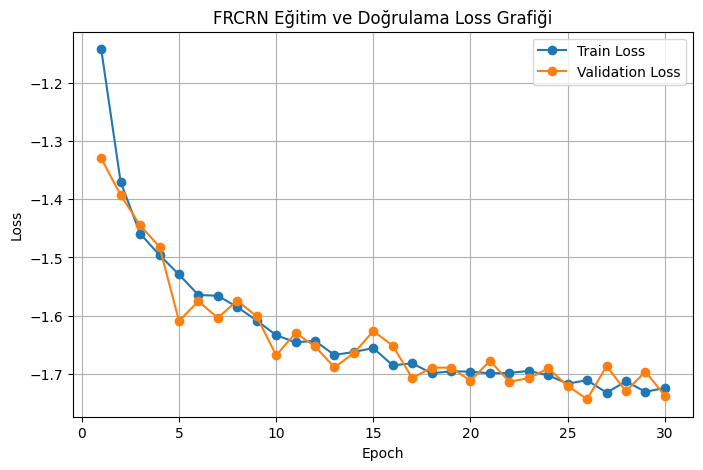

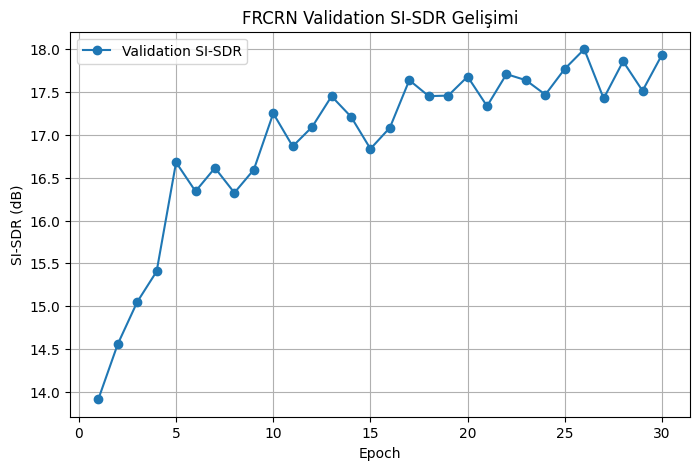

En iyi Validation SI-SDR: 17.99907323564802
En iyi epoch: 26


In [28]:
# ============================================================
# FRCRN Notebook - Hücre 14
# Eğitim grafikleri: Loss ve SI-SDR
# ============================================================

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FRCRN Eğitim ve Doğrulama Loss Grafiği")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["val_si_sdr"], marker="o", label="Validation SI-SDR")
plt.xlabel("Epoch")
plt.ylabel("SI-SDR (dB)")
plt.title("FRCRN Validation SI-SDR Gelişimi")
plt.legend()
plt.grid(True)
plt.show()

print("En iyi Validation SI-SDR:", max(history["val_si_sdr"]))
print("En iyi epoch:", int(np.argmax(history["val_si_sdr"]) + 1))

In [29]:
# ============================================================
# FRCRN Notebook - Hücre 15
# Çoklu örnek ses karşılaştırması
# Noisy / Clean / Enhanced
# ============================================================

from IPython.display import Audio, display

sample_dir = OUT_DIR / "samples"
sample_dir.mkdir(parents=True, exist_ok=True)

NUM_DEMOS = 5
demo_indices = random.sample(range(len(val_dataset)), NUM_DEMOS)

for i, idx in enumerate(demo_indices):

    print("\n" + "=" * 60)
    print(f"ÖRNEK {i+1}")
    print("=" * 60)

    sample_noisy, sample_clean = val_dataset[idx]

    with torch.no_grad():
        sample_enhanced = enhance_batch(
            sample_noisy.unsqueeze(0)
        ).squeeze(0).cpu()

    noisy_np = sample_noisy.numpy()
    clean_np = sample_clean.numpy()
    enhanced_np = sample_enhanced.numpy()

    noisy_path = sample_dir / f"demo_{i+1}_noisy.wav"
    clean_path = sample_dir / f"demo_{i+1}_clean.wav"
    enhanced_path = sample_dir / f"demo_{i+1}_enhanced_frcrn.wav"

    write_wav(noisy_path, noisy_np, CFG["sample_rate"])
    write_wav(clean_path, clean_np, CFG["sample_rate"])
    write_wav(enhanced_path, enhanced_np, CFG["sample_rate"])

    print("🔊 Gürültülü:")
    display(Audio(noisy_np, rate=CFG["sample_rate"]))

    print("🎯 Temiz Referans:")
    display(Audio(clean_np, rate=CFG["sample_rate"]))

    print("✨ FRCRN Çıktısı:")
    display(Audio(enhanced_np, rate=CFG["sample_rate"]))

print("\n✅ Ses örnekleri kaydedildi:")
print(sample_dir)


ÖRNEK 1
🔊 Gürültülü:


🎯 Temiz Referans:


✨ FRCRN Çıktısı:



ÖRNEK 2
🔊 Gürültülü:


🎯 Temiz Referans:


...

✨ FRCRN Çıktısı:



ÖRNEK 5
🔊 Gürültülü:


🎯 Temiz Referans:


✨ FRCRN Çıktısı:



✅ Ses örnekleri kaydedildi:
/content/drive/MyDrive/SLESS_FRCRN/outputs/samples


In [30]:
# ============================================================
# FRCRN Notebook - Hücre 16
# Test metrikleri: SI-SDR, PESQ, STOI
# ============================================================

def torch_si_sdr_value(est_np, ref_np):
    est = torch.tensor(est_np, dtype=torch.float32).unsqueeze(0)
    ref = torch.tensor(ref_np, dtype=torch.float32).unsqueeze(0)
    return float(si_sdr(est, ref).mean().item())


def safe_pesq(clean_np, test_np, sr=16000):
    try:
        clean_np = np.asarray(clean_np, dtype=np.float32).reshape(-1)
        test_np = np.asarray(test_np, dtype=np.float32).reshape(-1)

        L = min(len(clean_np), len(test_np))
        clean_np = clean_np[:L]
        test_np = test_np[:L]

        return float(pesq(sr, clean_np, test_np, "wb"))
    except Exception:
        return np.nan


def safe_stoi(clean_np, test_np, sr=16000):
    try:
        clean_np = np.asarray(clean_np, dtype=np.float32).reshape(-1)
        test_np = np.asarray(test_np, dtype=np.float32).reshape(-1)

        L = min(len(clean_np), len(test_np))
        clean_np = clean_np[:L]
        test_np = test_np[:L]

        return float(stoi(clean_np, test_np, sr, extended=False))
    except Exception:
        return np.nan


eval_n = min(CFG["eval_items"], len(val_dataset))

rows = []

for i in tqdm(range(eval_n), desc="FRCRN metrik hesaplanıyor"):

    noisy, clean = val_dataset[i]

    with torch.no_grad():
        enhanced = enhance_batch(
            noisy.unsqueeze(0)
        ).squeeze(0).cpu()

    noisy_np = noisy.numpy()
    clean_np = clean.numpy()
    enhanced_np = enhanced.numpy()

    noisy_sisdr = torch_si_sdr_value(noisy_np, clean_np)
    enhanced_sisdr = torch_si_sdr_value(enhanced_np, clean_np)

    rows.append({
        "sample": i,
        "noisy_si_sdr": noisy_sisdr,
        "enhanced_si_sdr": enhanced_sisdr,
        "si_sdr_improvement": enhanced_sisdr - noisy_sisdr,

        "pesq_noisy": safe_pesq(clean_np, noisy_np, CFG["sample_rate"]),
        "pesq_enhanced": safe_pesq(clean_np, enhanced_np, CFG["sample_rate"]),

        "stoi_noisy": safe_stoi(clean_np, noisy_np, CFG["sample_rate"]),
        "stoi_enhanced": safe_stoi(clean_np, enhanced_np, CFG["sample_rate"]),
    })

metrics_df = pd.DataFrame(rows)

summary = {
    "model": "FRCRN",
    "eval_items": eval_n,

    "noisy_si_sdr_mean": float(metrics_df["noisy_si_sdr"].mean()),
    "enhanced_si_sdr_mean": float(metrics_df["enhanced_si_sdr"].mean()),
    "si_sdr_improvement_mean": float(metrics_df["si_sdr_improvement"].mean()),

    "pesq_noisy_mean": float(metrics_df["pesq_noisy"].mean()),
    "pesq_enhanced_mean": float(metrics_df["pesq_enhanced"].mean()),

    "stoi_noisy_mean": float(metrics_df["stoi_noisy"].mean()),
    "stoi_enhanced_mean": float(metrics_df["stoi_enhanced"].mean()),
}

metrics_path = OUT_DIR / "frcrn_metrics_per_sample.csv"
summary_path = OUT_DIR / "frcrn_metrics_summary.json"

metrics_df.to_csv(metrics_path, index=False)

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("✅ Metrikler hesaplandı")
print("CSV:", metrics_path)
print("Summary:", summary_path)

display(metrics_df.head())

print("\nÖzet sonuçlar:")
for k, v in summary.items():
    print(f"{k}: {v}")

FRCRN metrik hesaplanıyor:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Metrikler hesaplandı
CSV: /content/drive/MyDrive/SLESS_FRCRN/outputs/frcrn_metrics_per_sample.csv
Summary: /content/drive/MyDrive/SLESS_FRCRN/outputs/frcrn_metrics_summary.json


,sample,noisy_si_sdr,enhanced_si_sdr,si_sdr_improvement,pesq_noisy,pesq_enhanced,stoi_noisy,stoi_enhanced
0,0,12.851666,17.843361,4.991694,2.040363,2.742294,0.936515,0.966787
1,1,13.308816,19.298992,5.990176,2.431425,3.397545,0.997172,0.997828
2,2,19.124857,26.270323,7.145466,3.150601,3.655007,0.994614,0.993246
3,3,-0.902470,8.870057,9.772528,1.074181,1.364660,0.696624,0.779472
4,4,17.161434,23.879129,6.717695,2.733630,3.230612,0.999028,0.999104



Özet sonuçlar:
model: FRCRN
eval_items: 200
noisy_si_sdr_mean: 7.849987804638221
enhanced_si_sdr_mean: 18.506460530757906
si_sdr_improvement_mean: 10.656472726119683
pesq_noisy_mean: 1.572132477760315
pesq_enhanced_mean: 2.4697168564796446
stoi_noisy_mean: 0.8723137849799194
stoi_enhanced_mean: 0.9255793725265653


In [32]:
# ============================================================
# FRCRN Notebook - Hücre 17
# Özet metrik tablosu
# ============================================================

si_n = summary["noisy_si_sdr_mean"]
si_e = summary["enhanced_si_sdr_mean"]

pe_n = summary["pesq_noisy_mean"]
pe_e = summary["pesq_enhanced_mean"]

st_n = summary["stoi_noisy_mean"]
st_e = summary["stoi_enhanced_mean"]

print("\n" + "═"*55)
print(f"{'Metrik':<20} {'Gürültülü':>10} {'Temizlenmiş':>12} {'Fark':>8}")
print("─"*55)

print(f"{'SI-SDR (dB)':<20} {si_n:>10.2f} {si_e:>12.2f} {si_e-si_n:>+8.2f}")
print(f"{'PESQ (1-4.5)':<20} {pe_n:>10.3f} {pe_e:>12.3f} {pe_e-pe_n:>+8.3f}")
print(f"{'STOI (0-1)':<20} {st_n:>10.3f} {st_e:>12.3f} {st_e-st_n:>+8.3f}")

print("═"*55)

print("\n📊 Referans:")
print("   PESQ: 2.5-3.0 iyi | 3.0+ çok iyi")
print("   STOI: 0.85+ iyi  | 0.90+ çok iyi")
print("   SI-SDR: +8 dB iyi | +12 dB çok iyi")

print("\n✅ Sonuçlar Drive'a kaydedildi:")
print(summary_path)


═══════════════════════════════════════════════════════
Metrik                Gürültülü  Temizlenmiş     Fark
───────────────────────────────────────────────────────
SI-SDR (dB)                7.85        18.51   +10.66
PESQ (1-4.5)              1.572        2.470   +0.898
STOI (0-1)                0.872        0.926   +0.053
═══════════════════════════════════════════════════════

📊 Referans:
   PESQ: 2.5-3.0 iyi | 3.0+ çok iyi
   STOI: 0.85+ iyi  | 0.90+ çok iyi
   SI-SDR: +8 dB iyi | +12 dB çok iyi

✅ Sonuçlar Drive'a kaydedildi:
/content/drive/MyDrive/SLESS_FRCRN/outputs/frcrn_metrics_summary.json


In [33]:
# ============================================================
# FRCRN Notebook - Hücre 18
# Drive'a model + metrik + ses örnekleri yedekleme
# ============================================================

import shutil
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

backup_dir = Path(f"/content/frcrn_backup_{timestamp}")
backup_dir.mkdir(exist_ok=True)

# 1. Model checkpointleri
ckpt_backup = backup_dir / "models"
ckpt_backup.mkdir(exist_ok=True)

for f in MODEL_DIR.glob("*.pt"):
    shutil.copy2(f, ckpt_backup / f.name)
    print(f"✅ Model: {f.name} ({f.stat().st_size/1e6:.1f} MB)")

# 2. Output dosyaları
outputs_backup = backup_dir / "outputs"
outputs_backup.mkdir(exist_ok=True)

for f in OUT_DIR.glob("*"):
    if f.is_file():
        shutil.copy2(f, outputs_backup / f.name)
        print(f"✅ Output: {f.name}")

# 3. Sample sesler
sample_src = OUT_DIR / "samples"
sample_backup = backup_dir / "samples"
sample_backup.mkdir(exist_ok=True)

if sample_src.exists():
    for f in sample_src.glob("*.wav"):
        shutil.copy2(f, sample_backup / f.name)
        print(f"✅ Sample: {f.name}")

# 4. Log dosyaları
log_backup = backup_dir / "logs"
log_backup.mkdir(exist_ok=True)

if LOG_DIR.exists():
    for f in LOG_DIR.glob("*"):
        if f.is_file():
            shutil.copy2(f, log_backup / f.name)
            print(f"✅ Log: {f.name}")

# 5. ZIP oluştur ve Drive'a kaydet
zip_base = str(BASE_DIR / f"frcrn_backup_{timestamp}")
shutil.make_archive(zip_base, "zip", str(backup_dir))

shutil.rmtree(backup_dir)

final_zip = Path(zip_base + ".zip")
size_mb = final_zip.stat().st_size / 1e6

print("\n📦 FRCRN yedek tamamlandı")
print("Dosya:", final_zip)
print(f"Boyut: {size_mb:.1f} MB")

✅ Model: frcrn_last_model.pt (124.0 MB)
✅ Model: frcrn_best_model.pt (124.0 MB)
✅ Output: frcrn_metrics_per_sample.csv
✅ Output: frcrn_metrics_summary.json
✅ Sample: demo_1_noisy.wav
✅ Sample: demo_1_clean.wav
✅ Sample: demo_1_enhanced_frcrn.wav
✅ Sample: demo_2_noisy.wav
✅ Sample: demo_2_clean.wav
✅ Sample: demo_2_enhanced_frcrn.wav
✅ Sample: demo_3_noisy.wav
✅ Sample: demo_3_clean.wav
✅ Sample: demo_3_enhanced_frcrn.wav
✅ Sample: demo_4_noisy.wav
✅ Sample: demo_4_clean.wav
✅ Sample: demo_4_enhanced_frcrn.wav
✅ Sample: demo_5_noisy.wav
✅ Sample: demo_5_clean.wav
✅ Sample: demo_5_enhanced_frcrn.wav

📦 FRCRN yedek tamamlandı
Dosya: /content/drive/MyDrive/SLESS_FRCRN/frcrn_backup_20260527_0127.zip
Boyut: 228.5 MB
